## SABR: a stochastic-vol model that gives a smile formula

SABR stands for **Stochastic Alpha Beta Rho**, after the stochastic volatility
and three of its four parameters ($\alpha$ level, $\beta$ backbone, $\rho$ skew).
The fourth parameter, $\nu$ (vol-of-vol, controlling curvature), is not in the
acronym but is just as essential.

### Why another model, and how it differs from SVI

SVI is a static shape. It fits one slice beautifully but has no dynamics, no
story about how volatility itself moves. SABR (Stochastic Alpha Beta Rho,
Hagan et al. 2002) is a genuine stochastic volatility model: it posits an SDE
for the forward and a second SDE for its volatility, and from those dynamics it
produces a smile. So where SVI *describes* a smile, SABR *generates* one from
assumptions about how the world moves.

The reason SABR is used everywhere in rates and FX desks, despite Heston also
being a stochastic-vol model, is a single practical fact: SABR comes with a
closed-form asymptotic formula for implied volatility. No Fourier inversion, no
PDE solve, no Monte Carlo. You plug the four parameters into an algebraic
expression and get the Black implied vol at any strike directly. That makes
calibration almost trivially fast, which is why it became the market standard
for quoting and interpolating smiles.

### The model

SABR describes the forward $F_t$ and its volatility $\alpha_t$ under the
forward measure:

$$dF_t = \alpha_t \, F_t^{\beta} \, dW_t^F$$
$$d\alpha_t = \nu \, \alpha_t \, dW_t^{\alpha}$$
$$dW_t^F \, dW_t^{\alpha} = \rho \, dt$$

Read each piece:

- $F_t$ is the forward (not spot), which is why your parity-implied forward is
  exactly the right input. SABR is natively a forward-measure model.
- $\alpha_t$ is the instantaneous volatility, itself stochastic. It follows a
  driftless geometric Brownian motion, so it is a lognormal vol-of-vol process,
  always positive, no mean reversion.
- The four parameters are:
  - $\alpha$ (alpha): the initial volatility level, sets the overall height of
    the smile (roughly the ATM vol).
  - $\beta$ (beta): the backbone exponent, $0 \le \beta \le 1$, controlling how
    the ATM vol moves as the forward moves. It sets the assumed
    forward-vol relationship.
  - $\rho$ (rho): the correlation between forward and vol shocks, sets the
    skew, exactly as in SVI and Heston. Negative $\rho$ steepens the left wing.
  - $\nu$ (nu): the vol-of-vol, how erratic the volatility is, controls the
    curvature (smile convexity). $\nu \to 0$ collapses the smile toward flat.

Four parameters, and they map cleanly onto the four things you can see in a
smile: level ($\alpha$), backbone/skew-vs-level tradeoff ($\beta$), skew
($\rho$), and curvature ($\nu$).

### The role of beta, and why it is usually fixed

$\beta$ is the parameter that makes SABR subtle. It interpolates between two
classic model regimes:

- $\beta = 1$: the forward is lognormal (like Black-Scholes). ATM vol is roughly
  invariant as the forward moves. This is the usual choice for equity and FX.
- $\beta = 0$: the forward is normal (Bachelier / normal model). ATM vol scales
  inversely with the forward. Common for rates, especially when forwards can go
  negative.
- $\beta = 0.5$: the CIR-like square-root regime, sometimes used for rates.

The important practical point: $\beta$ and $\rho$ are badly identified from a
single smile. Both affect the skew, so a fit can trade one off against the other
and land almost anywhere along a ridge. The standard resolution is to *fix*
$\beta$ a priori (from the asset class or from how the ATM vol/forward
relationship behaves historically) and calibrate only $(\alpha, \rho, \nu)$.
This is the same identifiability lesson from SVI, two parameters fighting over
the same observable feature, resolved here by pinning one rather than by a
reparametrization.

### The Hagan implied-vol formula

The value of SABR is that the model above has an asymptotic expansion (small
time to expiry, or equivalently a short-maturity / weak-vol-of-vol limit) for
the Black implied volatility. For a forward $F$, strike $K$, expiry $T$:

$$\sigma_B(K, F) = \frac{\alpha}
{(FK)^{(1-\beta)/2}\left[1 + \frac{(1-\beta)^2}{24}\log^2\frac{F}{K}
+ \frac{(1-\beta)^4}{1920}\log^4\frac{F}{K}\right]}
\cdot \frac{z}{x(z)} \cdot \left[1 + \Big(\cdots\Big) T \right]$$

with

$$z = \frac{\nu}{\alpha}(FK)^{(1-\beta)/2}\log\frac{F}{K}, \qquad
x(z) = \log\!\left(\frac{\sqrt{1 - 2\rho z + z^2} + z - \rho}{1 - \rho}\right)$$

and the $T$-order correction term in brackets:

$$1 + \left[\frac{(1-\beta)^2}{24}\frac{\alpha^2}{(FK)^{1-\beta}}
+ \frac{1}{4}\frac{\rho\beta\nu\alpha}{(FK)^{(1-\beta)/2}}
+ \frac{2 - 3\rho^2}{24}\nu^2\right] T$$

It looks forbidding, but it is just an algebraic function of the four parameters
and $(K, F, T)$. Three structural things to notice, which matter more than the
exact coefficients:

1. The leading factor $\alpha / (FK)^{(1-\beta)/2}$ is the level. At the money it
   reduces to $\alpha / F^{1-\beta}$, the ATM vol, which is why $\alpha$ is
   essentially "the ATM vol knob."

2. The $z / x(z)$ factor carries the skew and is where $\rho$ and $\nu$ enter.
   As $K \to F$ (at the money), $z \to 0$ and $z/x(z) \to 1$, so this factor is
   a pure smile-shape multiplier that switches off at the money.

3. The $[1 + (\cdots)T]$ bracket is the small-time correction. It is a genuine
   approximation term, and it is the source of SABR's known failure mode.

### The ATM special case

At $K = F$ the formula collapses (the $\log(F/K)$ terms vanish) to a clean
expression:

$$\sigma_{ATM} = \frac{\alpha}{F^{1-\beta}}
\left[1 + \left(\frac{(1-\beta)^2}{24}\frac{\alpha^2}{F^{2-2\beta}}
+ \frac{1}{4}\frac{\rho\beta\nu\alpha}{F^{1-\beta}}
+ \frac{2 - 3\rho^2}{24}\nu^2\right)T\right]$$

This is worth implementing separately and testing against, because it is the
$K \to F$ limit of the general formula, and if the general formula does not
converge to this as $K \to F$ you have a bug. It is also numerically important:
the general formula has $\log(F/K)$ in denominators, so evaluating exactly at
$K = F$ divides by zero. The code must branch to the ATM expression near the
money, the same removable-singularity handling you have hit before.

### Where SABR breaks, and why we still use it

The Hagan formula is an *asymptotic approximation*, valid for short maturities
and modest vol-of-vol. It has two well-known failure modes:

- **Long maturities / high vol-of-vol**: the $O(T)$ truncation degrades, and the
  approximation drifts from the true SABR model price.
- **Low strikes**: the formula can produce an implied *density* that goes
  negative in the left wing (a butterfly arbitrage), especially for low $\beta$
  and long $T$. This is the SABR analogue of the Durrleman condition you built
  for SVI, and it is why practitioners either use the model only where it is
  well-behaved, or switch to arbitrage-free variants (Hagan's own 2014
  arbitrage-free PDE, or Antonov's exact formulas).

So SABR occupies a different point in the tradeoff space than SVI or Heston. SVI
is arbitrage-free by construction (once you enforce $g \ge 0$) but has no
dynamics. Heston has full dynamics and is arbitrage-free but needs Fourier
pricing. SABR has dynamics *and* a closed-form smile, at the cost of being an
approximation that can violate arbitrage in the wings. For calibration speed and
market-standard quoting it wins; for a guaranteed-clean surface it does not.

### What we will build

The calibration mirrors the SVI structure closely, which is the point of doing
it second:

1. `sabr_vol(K, F, T, alpha, beta, rho, nu)`: the Hagan formula, with a branch
   to the ATM expression near $K = F$.
2. Validation: confirm the general formula converges to the ATM formula as
   $K \to F$ (the removable singularity), and that a flat smile emerges as
   $\nu \to 0$.
3. Fix $\beta$ (equity convention $\beta = 1$, or test a couple of values), then
   calibrate $(\alpha, \rho, \nu)$ to the same CBOE slice we fit with SVI, by
   least squares on implied vols.
4. Overlay the SABR fit on the SVI fit for the same slice, and compare: two
   different philosophies fitting the same market, one a static shape, one a
   dynamic model.

In [1]:
# Imports & Constants
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from data.option_chain import (
    fetch_chain_cboe, filter_by_expiry, clean_chain,
    find_closest_expiry, implied_forward_from_parity,
)
from calibration.implied_vol import bsm_implied_vol
from models.bsm import bsm_vega
from models.sabr import sabr_vol, sabr_atm_vol
from calibration.sabr import calibrate_sabr, SABRParams

R = 0.045

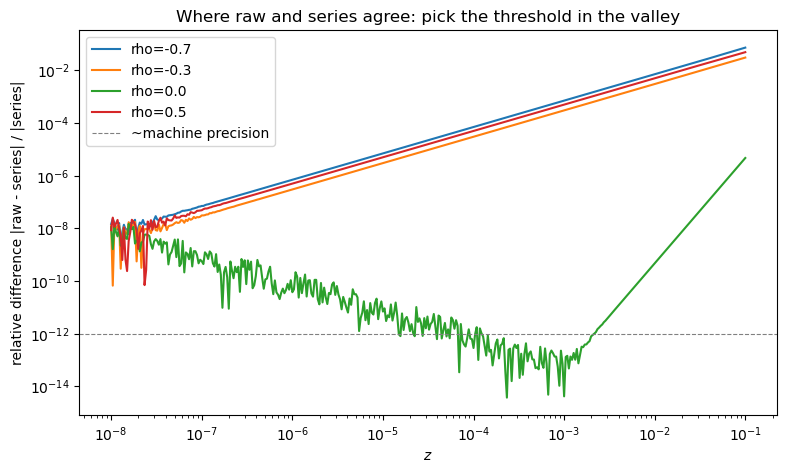

In [2]:
# Threshold experiment: where does raw z/x(z) lose precision vs the series?
# Run this once, read the threshold off the plot, then hardcode it in sabr_vol.
def zx_raw(z, rho):
    """Direct z/x(z), accurate for large |z|, cancellation-prone near 0."""
    x = np.log((np.sqrt(1.0 - 2.0*rho*z + z**2) + z - rho) / (1.0 - rho))
    return z / x

def zx_series(z, rho):
    """Small-z expansion, accurate near 0."""
    return 1.0 + rho*z/2.0 + (2.0 - 3.0*rho**2)*z**2/12.0

z_vals = np.logspace(-8, -1, 400)          # 1e-8 up to 1e-1
rhos = [-0.7, -0.3, 0.0, 0.5]

fig, ax = plt.subplots(figsize=(9, 5))
for rho in rhos:
    raw = zx_raw(z_vals, rho)
    series = zx_series(z_vals, rho)
    rel_diff = np.abs(raw - series) / np.abs(series)
    ax.loglog(z_vals, rel_diff, lw=1.5, label=f"rho={rho}")

ax.axhline(1e-12, color="gray", lw=0.8, ls="--", label="~machine precision")
ax.set_xlabel("$z$")
ax.set_ylabel("relative difference |raw - series| / |series|")
ax.set_title("Where raw and series agree: pick the threshold in the valley")
ax.legend()
plt.show()

## Fitting to Real SPX CBOE data

In [3]:
from data.option_chain import fetch_chain_cboe, build_slice
from calibration.implied_vol import bsm_implied_vol
from models.bsm import bsm_vega

all_opts, spot = fetch_chain_cboe("^SPX")
s = build_slice(all_opts, spot, target_days=30, r=R,
                bsm_implied_vol=bsm_implied_vol, bsm_vega=bsm_vega)
k, iv_market, weights, F, T = s["k"], s["iv"], s["weights"], s["F"], s["T"]

In [5]:
F, T, dte, expiry = s["F"], s["T"], s["dte"], s["expiry"]
otm = s["otm"]   # keep the frame around for plotting later

print(f"{expiry}, {dte} DTE, F={F:.2f}, {len(k)} strikes")

2026-09-18, 30 DTE, F=7708.88, 440 strikes


In [6]:
# how many strikes at each stage?
expiries = sorted(all_opts["expiry"].unique())
exp, d = find_closest_expiry(expiries, 30)
print(f"expiry {exp}, dte {d}")

c_raw, p_raw = filter_by_expiry(all_opts, exp)
print(f"raw: {len(c_raw)} calls, {len(p_raw)} puts")

c = clean_chain(c_raw, source="cboe", verbose=True)
p = clean_chain(p_raw, source="cboe", verbose=True)
print(f"cleaned: {len(c)} calls, {len(p)} puts")

expiry 2026-09-18, dte 30
raw: 989 calls, 989 puts
Started: 989 rows
After bid > 0:               948
After spread filter:         885
After volume filter:         215
After open interest filter:  213
After staleness filter:      213
Started: 989 rows
After bid > 0:               944
After spread filter:         877
After volume filter:         343
After open interest filter:  342
After staleness filter:      342
cleaned: 213 calls, 342 puts


In [7]:
F_check, _ = implied_forward_from_parity(c, p, r=R, T=30/365)
c2 = c.copy(); c2["k"] = np.log(c2["strike"] / F_check)
p2 = p.copy(); p2["k"] = np.log(p2["strike"] / F_check)
otm_check = pd.concat([p2[p2["k"] < 0], c2[c2["k"] >= 0]])
print(f"after OTM selection: {len(otm_check)}")
print(f"after |k|<0.4 band:  {len(otm_check[otm_check['k'].abs() < 0.4])}")
print(f"k range: {otm_check['k'].min():.3f} to {otm_check['k'].max():.3f}")

after OTM selection: 441
after |k|<0.4 band:  440
k range: -0.413 to 0.074


In [9]:
sabr_params, sabr_rmse = calibrate_sabr(
    k, iv_market, F, T, beta=1.0, weights=weights,
)

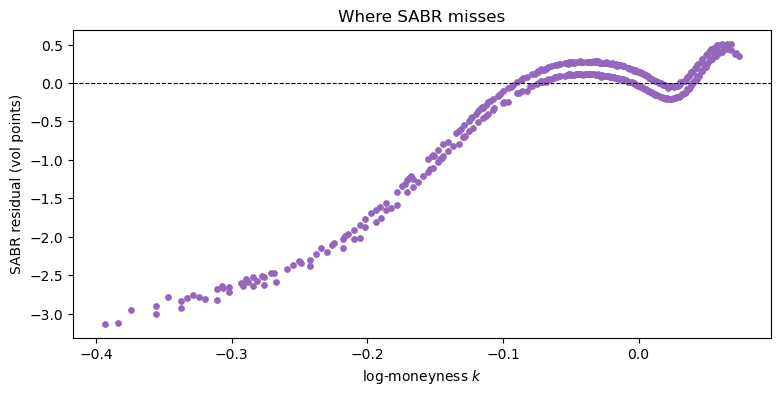

In [12]:
K = F * np.exp(k)
model_iv = sabr_vol(K, F, T, sabr_params.alpha, sabr_params.beta,
                    sabr_params.rho, sabr_params.nu)
resid = model_iv - iv_market

fig, ax = plt.subplots(figsize=(9, 4))
ax.scatter(k, resid * 100, s=15, color="tab:purple")  # in vol points (%)
ax.axhline(0, color="black", lw=0.8, ls="--")
ax.set_xlabel("log-moneyness $k$")
ax.set_ylabel("SABR residual (vol points)")
ax.set_title("Where SABR misses")
plt.show()

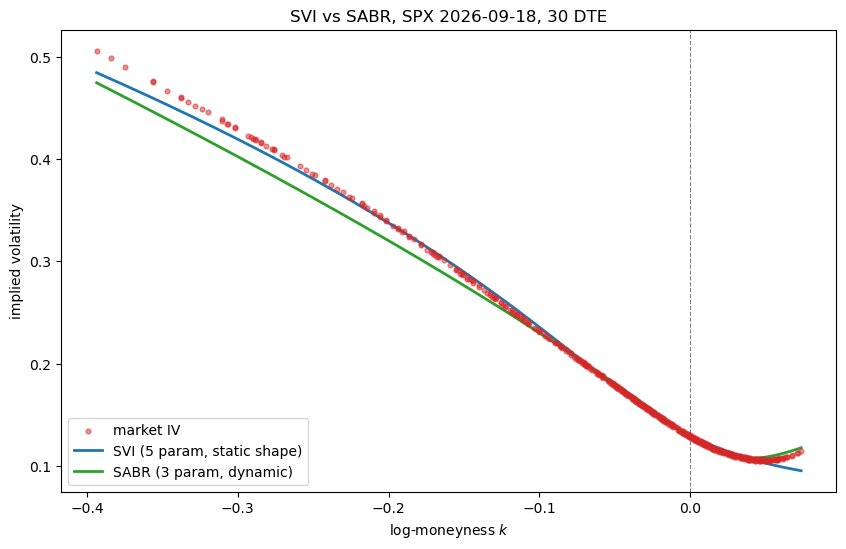

In [13]:
from calibration.svi import fit_slice, svi_raw

w = s["w"]
svi_result = fit_slice(k, w, weights=weights, lam=0.0)

# convert both fits to vol space for a fair overlay
k_dense = np.linspace(k.min(), k.max(), 400)
K_dense = F * np.exp(k_dense)

svi_vol = np.sqrt(svi_raw(k_dense, svi_result.params) / T)
sabr_vol_curve = sabr_vol(K_dense, F, T, sabr_params.alpha, sabr_params.beta,
                          sabr_params.rho, sabr_params.nu)

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(k, iv_market, s=12, color="tab:red", alpha=0.5, label="market IV", zorder=3)
ax.plot(k_dense, svi_vol, color="tab:blue", lw=2, label="SVI (5 param, static shape)")
ax.plot(k_dense, sabr_vol_curve, color="tab:green", lw=2, label="SABR (3 param, dynamic)")
ax.axvline(0, color="gray", lw=0.8, ls="--")
ax.set_xlabel("log-moneyness $k$")
ax.set_ylabel("implied volatility")
ax.set_title(f"SVI vs SABR, SPX {expiry}, {dte} DTE")
ax.legend()
plt.show()

### SVI vs SABR: what the comparison teaches

Both models were fit to the same SPX slice. Reading the overlay and the
residual plot together gives a concrete, empirical account of how they differ,
beyond the textbook description.

**Near the money they are indistinguishable.** For $-0.1 < k < 0.05$ the two
curves sit on top of each other and on the market. Both capture the ATM level
and local skew perfectly. This is where Hagan's asymptotics are most accurate
(small $|k|$) and where both models have full expressive power. No model is
distinguished by its ATM fit.

**In the wings they diverge, and SVI wins on fit.** Below $k = -0.15$ the SABR
curve peels away underneath the market, underpricing the deep downside vol, and
the gap widens with depth (reaching about 3 vol points at $k = -0.4$). SVI
tracks the steep put skew far better. Two reasons combine:

- SABR's Hagan formula is an *asymptotic approximation*, valid for small $|k|$
  and small $T$. A 30 DTE slice at $k = -0.4$ is well outside that comfort zone,
  so the formula runs out of road in the wing. This is a documented, expected
  failure mode, not a calibration error.
- SVI has five free parameters and no dynamics to respect, so it can contort to
  hug the data. SABR, with $\beta$ fixed, has three effective parameters, and
  they must correspond to a real SDE. That constraint is exactly what SABR buys
  you (a dynamic model, not just a shape), and exactly what costs it wing
  accuracy here.

**The residual reveals two separate misfits.** The SABR residual is not a
uniform offset. It has (a) a steep monotone drift in the deep left wing (the
asymptotic breakdown above), and (b) a gentle S-shaped wiggle through the body.
The wiggle is the signature of a model with too few shape degrees of freedom:
SABR fits the gross level, skew, and curvature but has nothing left for the
finer local bending, so the misfit alternates sign as its fixed shape crosses
over and under the true smile. SVI's extra parameters absorb exactly that
wiggle.

**Where there is no data, they disagree freely.** Past the last call quote
($k > 0.04$) the curves split, one turning up, one down, with nothing to pin
either. A practical reminder: two models agreeing perfectly on quoted strikes
can diverge sharply on extrapolated ones. Never trust a fitted smile outside
its strike range.

**The tradeoff, made concrete.** Neither model is better in the abstract:

- **SVI**: a flexible static shape. Fits the smile to near-zero residual,
  arbitrage-free once $g \ge 0$ is enforced, but carries no dynamics, it cannot
  tell you how the smile evolves. Use it as a clean interpolation target and to
  supply an arbitrage-free surface for other models to calibrate against.
- **SABR**: a genuine stochastic-vol model with a fast closed-form smile.
  Captures the smile's structure and comes with dynamics, but is an
  approximation that degrades in the deep wing and can violate arbitrage there.
  Use it for fast market-standard quoting and interpolation where you also want
  a dynamic story, and accept wing error.

SVI and SABR agree where fitting is easy (ATM) and diverge where it is hard
(wings), with SVI's flexibility tracking the steep downside that SABR's
constrained dynamic form cannot. That is the flexibility-versus-dynamics
tradeoff, seen on real SPX rather than asserted.